In [4]:
import pandas as pd
from sqlalchemy import create_engine, text

pd.set_option('display.max_columns', None)

print("Libraries loaded")

Libraries loaded


In [5]:
df = pd.read_csv("../data/processed/cleaned_transactions.csv", parse_dates=['InvoiceDate'])

print("Shape:", df.shape)
df.head()

Shape: (805549, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [8]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

DB_USER = "postgres"
DB_PASSWORD = "Abhipushp@2002"
DB_HOST = "localhost"
DB_PORT = 5432
DB_NAME = "ecommerce_rfm"

connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME
)

engine = create_engine(connection_url)

# Test connection
with engine.connect() as conn:
    print("Connected to PostgreSQL")

Connected to PostgreSQL


In [9]:
df.to_sql('transactions', engine, if_exists='replace', index=False)

print("Data loaded into 'transactions' table")

with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM transactions"))
    print("Row count in table:", result.scalar())

Data loaded into 'transactions' table
Row count in table: 805549


In [10]:
query_revenue_by_country = """
SELECT
    "Country",
    ROUND(SUM("TotalPrice")::numeric, 2) AS total_revenue,
    COUNT(DISTINCT "Invoice") AS num_orders
FROM transactions
GROUP BY "Country"
ORDER BY total_revenue DESC
LIMIT 10;
"""

revenue_by_country = pd.read_sql(query_revenue_by_country, engine)
revenue_by_country

,Country,total_revenue,num_orders
0,United Kingdom,14723147.52,33541
1,EIRE,621631.11,567
2,Netherlands,554232.34,228
3,Germany,431262.46,789
4,France,355257.47,614
5,Australia,169968.11,95
6,Spain,109178.53,154
7,Switzerland,100365.34,90
8,Sweden,91549.72,104
9,Denmark,69862.19,43


In [11]:
query_revenue_by_month = """
SELECT
    DATE_TRUNC('month', "InvoiceDate") AS month,
    ROUND(SUM("TotalPrice")::numeric, 2) AS total_revenue,
    COUNT(DISTINCT "Invoice") AS num_orders
FROM transactions
GROUP BY month
ORDER BY month;
"""

revenue_by_month = pd.read_sql(query_revenue_by_month, engine)
revenue_by_month

,month,total_revenue,num_orders
0,2009-12-01,686654.16,1512
1,2010-01-01,557319.06,1011
2,2010-02-01,506371.07,1104
3,2010-03-01,699608.99,1524
4,2010-04-01,594609.19,1329
5,2010-05-01,599985.79,1377
6,2010-06-01,639066.58,1497
7,2010-07-01,591636.74,1381
8,2010-08-01,604242.65,1293
9,2010-09-01,831615.00,1689


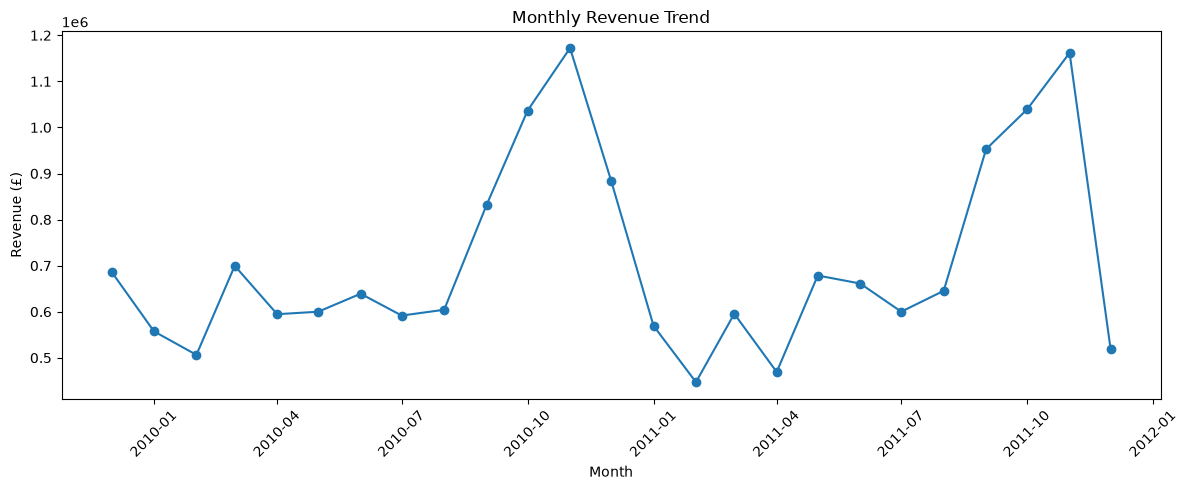

Saved: ../images/monthly_revenue_trend.png


In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    revenue_by_month['month'],
    revenue_by_month['total_revenue'],
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('../images/monthly_revenue_trend.png', dpi=150)

plt.show()

print("Saved: ../images/monthly_revenue_trend.png")

In [13]:
query_repeat_customers = """
WITH customer_orders AS (
    SELECT
        "Customer ID",
        COUNT(DISTINCT "Invoice") AS order_count
    FROM transactions
    GROUP BY "Customer ID"
)
SELECT
    CASE
        WHEN order_count > 1 THEN 'Repeat Customer'
        ELSE 'One-Time Customer'
    END AS customer_type,
    COUNT(*) AS num_customers,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS percentage
FROM customer_orders
GROUP BY customer_type;
"""

repeat_vs_onetime = pd.read_sql(query_repeat_customers, engine)
repeat_vs_onetime

,customer_type,num_customers,percentage
0,One-Time Customer,1623,27.61
1,Repeat Customer,4255,72.39


In [14]:
query_top_products = """
SELECT
    "StockCode",
    "Description",
    ROUND(SUM("TotalPrice")::numeric, 2) AS total_revenue,
    SUM("Quantity") AS total_quantity_sold
FROM transactions
GROUP BY "StockCode", "Description"
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_products = pd.read_sql(query_top_products, engine)
top_products

,StockCode,Description,total_revenue,total_quantity_sold
0,22423,REGENCY CAKESTAND 3 TIER,286486.30,24899.0
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,252072.46,93640.0
2,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995.0
3,M,Manual,152340.57,9803.0
4,85099B,JUMBO BAG RED RETROSPOT,136980.08,75759.0
5,84879,ASSORTED COLOUR BIRD ORNAMENT,127074.17,79913.0
6,POST,POSTAGE,126563.04,5333.0
7,47566,PARTY BUNTING,103880.23,23607.0
8,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916.0
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,79594.33,29477.0


In [15]:
query_customer_ranking = """
SELECT
    "Customer ID",
    ROUND(SUM("TotalPrice")::numeric, 2) AS total_spend,
    RANK() OVER (ORDER BY SUM("TotalPrice") DESC) AS spend_rank
FROM transactions
GROUP BY "Customer ID"
ORDER BY spend_rank
LIMIT 10;
"""

customer_ranking = pd.read_sql(query_customer_ranking, engine)
customer_ranking

,Customer ID,total_spend,spend_rank
0,18102,608821.65,1
1,14646,528602.52,2
2,14156,313946.37,3
3,14911,295972.63,4
4,17450,246973.09,5
5,13694,196482.81,6
6,17511,175603.55,7
7,16446,168472.50,8
8,16684,147142.77,9
9,12415,144458.37,10


In [17]:
revenue_by_country.to_csv(
    "../data/processed/sql_revenue_by_country.csv",
    index=False
)

revenue_by_month.to_csv(
    "../data/processed/sql_revenue_by_month.csv",
    index=False
)

repeat_vs_onetime.to_csv(
    "../data/processed/sql_repeat_vs_onetime.csv",
    index=False
)

top_products.to_csv(
    "../data/processed/sql_top_products.csv",
    index=False
)

print("All SQL analysis outputs saved")

All SQL analysis outputs saved
